# Qiskit Crash Course
This notebook provides a quick introduction to Qiskit, focusing on the tools we use in Block 3 for simulating the Kitaev chain.

## 1. Basic Circuit Construction and Simulation

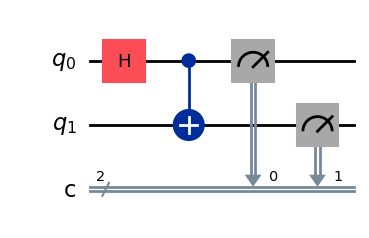

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Create a Quantum Circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate on qubit 0 (puts it in a superposition)
qc.h(0)

# Apply a CNOT gate with control qubit 0 and target qubit 1
qc.cx(0, 1)

# Measure both qubits into the classical bits
qc.measure([0, 1], [0, 1])

# Draw the circuit
qc.draw('mpl')

Measurement counts: {'11': 514, '00': 486}


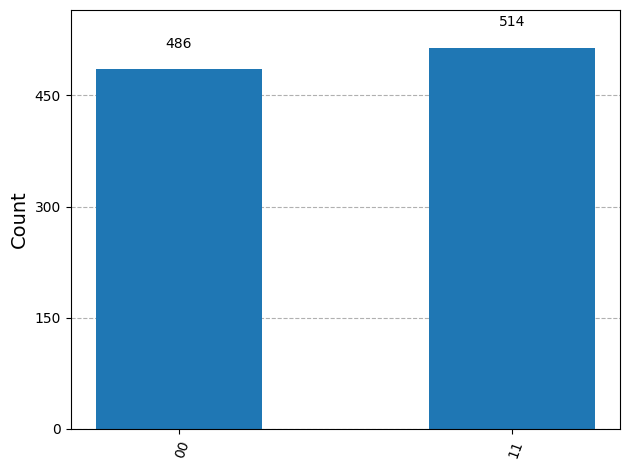

In [2]:
# Simulate the circuit
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
result = job.result()
counts = result.get_counts()

print("Measurement counts:", counts)
plot_histogram(counts)

## 2. Parameterized Quantum Circuits (PQCs)
Parameterized circuits are the foundation of Variational Quantum Eigensolver (VQE) algorithms.

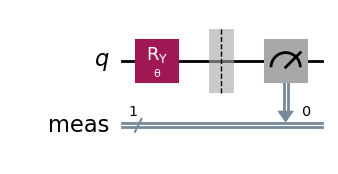

Counts after applying Ry(pi): {'1': 1000}


In [3]:
from qiskit.circuit import Parameter
import numpy as np
from qiskit import transpile

theta = Parameter('θ')
pqc = QuantumCircuit(1)
pqc.ry(theta, 0)
pqc.measure_all()

display(pqc.draw('mpl'))

# Assign a value to the parameter (np.pi creates a full bit-flip for Ry)
bound_circuit = pqc.assign_parameters({theta: np.pi})

# Run
bound_circuit = transpile(bound_circuit, simulator)
#bound_circuit=None
job = simulator.run(bound_circuit, shots=1000)
print("Counts after applying Ry(pi):", job.result().get_counts())

## 3. Observables and Primitives
In physics simulations, we often want to measure expectation values of Hamiltonians. Qiskit's `SparsePauliOp` and `Estimator` primitive make this easy.

In [4]:
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import Estimator

# Define an observable: Z on qubit 0 and Z on qubit 1
# Note: Qiskit uses little-endian ordering. String 'IX' means X on qubit 0 and I on qubit 1.
observable = SparsePauliOp(['ZZ', 'IX'], [1.0, 0.5])
print("Observable:\n", observable)

# Prepare a state (e.g., |01>)
state_circuit = QuantumCircuit(2)
state_circuit.x(0) # State becomes |01> (little endian: q1=0, q0=1)

# Evaluate expectation value <psi| Observable |psi>
# Estimator handles the exact or shot-based expectation value computation.
estimator = Estimator(approximation=True)
job = estimator.run(state_circuit, observable)
result = job.result()
print("\nExpectation value:", result.values[0])

Observable:
 SparsePauliOp(['ZZ', 'IX'],
              coeffs=[1. +0.j, 0.5+0.j])

Expectation value: -1.0
